# 05 — Cumulative host-mass sweep: growing the range from 12.0–12.5 outward

Same catalog and fitting machinery as `05_compare_hostmass_noradiuscut.ipynb`, but instead of a few
fixed windows it does a **cumulative sweep**: the host-mass selection starts at **12.0–12.5** and
the **upper limit grows by `HI_STEP` (0.5 dex) each step** (12.0–12.5, 12.0–13.0, 12.0–13.5, …),
with the **lower bound fixed at 12.0**. So each step adds the next shell of more massive hosts.

For each cumulative window it fits the anisotropy $p(\theta)\propto1+A\cos2\theta$ and the quench
fraction $f_q(\theta)=a+b\cos2\theta$, then shows:

1. **overlaid $P(\theta)$ fits** (colored by the upper mass limit),
2. **overlaid $f_q(\theta)$ fits** (colored by the upper mass limit), and
3. **trend panels**: the anisotropy $A$ and the quench parameters $a$, $b$ **as a function of the
   host-mass range included** (i.e. vs the upper limit $12.0<\log M_{200c}<x$).

Radius cut, redshift, satellite cuts, and the sweep bounds stay flexible. `RADIUS_CUT` defaults to
`False` (all radii) as in the no-radius-cut notebook.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import emcee
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

warnings.filterwarnings("ignore")
%matplotlib inline
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})

# ================= CONFIG — change these and re-run =================
DATA_ROOT = "../data2"
BASE_CAT  = "tng_satellites_hostlogM12.0plus_logM7.00.csv"   # open catalog from 01_generate_catalogs_massive

REDZ         = "z0"            # "z0" (z=0) or "z0p05" (z=0.05)
RADIUS_CUT   = False          # True -> keep d_r200_3d < R200C_FACTOR; False -> all radii
R200C_FACTOR = 1.0            # aperture in R_200c (only used when RADIUS_CUT)

# cumulative sweep: fixed lower bound, upper bound grows by HI_STEP each step
HOST_LO   = 12.0              # fixed lower bound (log10 M200c)
HI_START  = 12.5             # first upper bound
HI_STEP   = 0.5              # increase the upper bound by this each step
HI_MAX    = 14.5             # last upper bound

# what each panel shows: (sim, satellite log10 M* cut)
PANELS = [
    ("tng100", 8.0),          # TNG100: M*_sat > 1e8
    ("tng50",  7.0),          # TNG50:  M*_sat > 1e7
]
SIMCOL = {"tng100": "#1f77b4", "tng50": "#d62728"}
# ===================================================================

# cumulative windows: (label, (lo, hi), upper-limit value)
HIS = np.round(np.arange(HI_START, HI_MAX + 1e-9, HI_STEP), 2)
CUM_WINDOWS = [(f"{HOST_LO:.1f}-{hi:.1f}", (HOST_LO, float(hi)), float(hi)) for hi in HIS]

# 18 angle bins over [0, 90]
N_BINS        = 18
ANGLE_EDGES   = np.linspace(0, 90, N_BINS + 1)
ANGLE_CENTERS = 0.5 * (ANGLE_EDGES[:-1] + ANGLE_EDGES[1:])

_rc = f"within {R200C_FACTOR:g} R200c" if RADIUS_CUT else "no radius cut"
# color each window by its upper limit
_norm = Normalize(vmin=HIS.min(), vmax=HIS.max())
_cmap = plt.cm.viridis
WIN_COLOR = {lab: _cmap(_norm(hi)) for lab, _, hi in CUM_WINDOWS}
print(f"z: {REDZ} | radius: {_rc} | cumulative windows: {[w[0] for w in CUM_WINDOWS]}")

z: z0 | radius: no radius cut | cumulative windows: ['12.0-12.5', '12.0-13.0', '12.0-13.5', '12.0-14.0', '12.0-14.5']


## Helpers — $P(\theta)$, the $A$ fit, and the quench-fraction sinusoid

Identical to `notebooks2/03`–`05`.

In [2]:
def norm_hist(theta):
    c, _ = np.histogram(theta, bins=ANGLE_EDGES)
    return c / c.sum() / (90.0 / N_BINS)

def model_curve(A):
    x = np.linspace(0, 90, 200)
    return x, (1.0 / 90.0) * (1.0 + A * np.cos(2 * np.radians(x)))

def fit_anisotropy(theta_deg, n_walkers=16, n_steps=4000, burn=1000, seed=0):
    '''MCMC of p(theta) ~ 1 + A cos(2 theta). Returns dict with A median/std/percentiles.'''
    th = np.radians(np.asarray(theta_deg, dtype=float))
    c2 = np.cos(2 * th); n = len(th)
    if n < 5:
        return dict(n=n, A=np.nan, Aerr=np.nan, lo=np.nan, hi=np.nan)

    def log_prob(p):
        A = p[0]
        if not (-0.999 < A < 0.999):
            return -np.inf
        v = 1.0 + A * c2
        if np.any(v <= 0):
            return -np.inf
        return np.sum(np.log(v))

    rng = np.random.default_rng(seed)
    p0 = rng.uniform(-0.1, 0.1, size=(n_walkers, 1))
    sampler = emcee.EnsembleSampler(n_walkers, 1, log_prob)
    sampler.run_mcmc(p0, n_steps, progress=False)
    chain = sampler.get_chain(discard=burn, flat=True)[:, 0]
    lo, med, hi = np.percentile(chain, [16, 50, 84])
    return dict(n=n, A=med, Aerr=chain.std(), lo=lo, hi=hi)

def bootstrap_fq(angle, quenched, N=5000, seed=0):
    '''Binned-mean quench fraction per angle bin, bootstrap mean and 1-sigma error.'''
    rng = np.random.default_rng(seed)
    angle = np.asarray(angle); quenched = np.asarray(quenched, dtype=float)
    n = len(angle)
    boot = np.full((N, N_BINS), np.nan)
    bin_idx = np.digitize(angle, ANGLE_EDGES) - 1
    for i in range(N):
        s = rng.integers(0, n, n)
        bi, qi = bin_idx[s], quenched[s]
        for j in range(N_BINS):
            m = bi == j
            if m.any():
                boot[i, j] = qi[m].mean()
    return np.nanmean(boot, axis=0), np.nanstd(boot, axis=0)

def _fq_log_prob(theta, x, y, sigma):
    a, b, f = theta
    if not (0 < a < 1 and -1 < b < 1 and -10 < f < 2):
        return -np.inf
    s = sigma ** 2 + np.exp(f) ** 2
    model = a + b * np.cos(2 * np.radians(x))
    return -0.5 * np.sum((y - model) ** 2 / s + np.log(2 * np.pi * s))

def fit_fq_sinusoid(mean, std, n_walkers=20, n_steps=6000, burn=1000, seed=0):
    '''MCMC fit of f_q = a + b cos(2 theta); returns (params_mean, params_std).'''
    np.random.seed(seed)
    ok = np.isfinite(mean) & np.isfinite(std) & (std > 0)
    if ok.sum() < 4:
        return np.array([np.nan] * 3), np.array([np.nan] * 3)
    p0 = np.array([0.5, 0.0, -3.0]) + 1e-2 * np.random.randn(n_walkers, 3)
    sampler = emcee.EnsembleSampler(n_walkers, 3, _fq_log_prob,
                                    args=(ANGLE_CENTERS[ok], mean[ok], std[ok]))
    sampler.run_mcmc(p0, n_steps, progress=False)
    chain = sampler.get_chain(discard=burn, flat=True)
    return chain.mean(axis=0), chain.std(axis=0)

def fq_band(p, e, n_mc=5000, seed=0):
    '''Posterior median + 16/84th-percentile band of f_q over [0, 90].'''
    rng = np.random.default_rng(seed)
    x = np.linspace(0, np.pi / 2, 300)
    a = rng.normal(p[0], e[0], n_mc); b = rng.normal(p[1], e[1], n_mc)
    yy = a[:, None] + b[:, None] * np.cos(2 * x)[None, :]
    return np.degrees(x), a.mean() + b.mean() * np.cos(2 * x), np.percentile(yy, 16, 0), np.percentile(yy, 84, 0)

## Load and fit each cumulative window

For every `(sim, cumulative window)` we post-select `12.0 < log M200c < hi`, the panel's satellite
floor, and the optional radius cut, then fit `A` and the quench `(a, b)`. The printed table shows
the running counts and fits as the mass range grows.

In [3]:
def load_sel(sim, logcut, window):
    path = os.path.join(DATA_ROOT, sim, REDZ, BASE_CAT)
    if not os.path.exists(path):
        print(f"[skip] missing {path}")
        return None
    df = pd.read_csv(path)
    hlo, hhi = window
    if hlo is not None: df = df[df["host_m200_phys"] > hlo]
    if hhi is not None: df = df[df["host_m200_phys"] < hhi]
    df = df[df["mstar_phys"] > logcut]
    if RADIUS_CUT:
        df = df[df["d_r200_3d"] < R200C_FACTOR]
    return df

data, quench, fits, fq_mean, fq_std, fq_p, fq_e = {}, {}, {}, {}, {}, {}, {}
print(f"{'dataset':<10s} {'window':<12s} {'hosts':>6s} {'sats':>7s} "
      f"{'A':>15s}  {'a':>14s}  {'b':>15s}")
for sim, logcut in PANELS:
    for hlabel, window, hi in CUM_WINDOWS:
        df = load_sel(sim, logcut, window)
        if df is None or len(df) == 0:
            continue
        key = (sim, hlabel)
        data[key]   = df["alpha"].to_numpy()
        quench[key] = df["quenched"].to_numpy(dtype=float)
        fits[key]   = fit_anisotropy(data[key], seed=1)
        m, s = bootstrap_fq(data[key], quench[key])
        fq_mean[key], fq_std[key] = m, s
        fq_p[key], fq_e[key] = fit_fq_sinusoid(m, s)
        f = fits[key]; p, e = fq_p[key], fq_e[key]
        print(f"{sim:<10s} {hlabel:<12s} {df['host_id'].nunique():>6d} {len(df):>7d} "
              f"{f['A']:+.3f}+/-{f['Aerr']:.3f}  {p[0]:.3f}+/-{e[0]:.3f}  {p[1]:+.3f}+/-{e[1]:.3f}")

dataset    window        hosts    sats               A               a                b
tng100     12.0-12.5       959    3198 +0.185+/-0.024  0.316+/-0.009  -0.027+/-0.012
tng100     12.0-13.0      1273    7052 +0.197+/-0.016  0.442+/-0.006  -0.029+/-0.009
tng100     12.0-13.5      1375   10720 +0.202+/-0.013  0.526+/-0.005  -0.018+/-0.007
tng100     12.0-14.0      1410   14719 +0.254+/-0.011  0.604+/-0.004  +0.004+/-0.006
tng100     12.0-14.5      1418   16870 +0.249+/-0.011  0.640+/-0.004  +0.004+/-0.005
tng50      12.0-12.5       117    1384 +0.156+/-0.038  0.568+/-0.014  -0.058+/-0.019
tng50      12.0-13.0       145    2140 +0.165+/-0.031  0.620+/-0.011  -0.049+/-0.015
tng50      12.0-13.5       159    3654 +0.184+/-0.023  0.701+/-0.008  -0.037+/-0.011
tng50      12.0-14.0       164    5084 +0.241+/-0.019  0.749+/-0.006  -0.017+/-0.009
tng50      12.0-14.5       165    5929 +0.226+/-0.018  0.779+/-0.006  -0.016+/-0.008


### Figure 1 — anisotropy $P(\theta)$ across the cumulative sweep

One panel per simulation; each cumulative window colored by its upper mass limit (dark → low,
yellow → high). Bold curve = posterior-median $\tfrac{1}{90}(1+A\cos2\theta)$; dotted = isotropic.

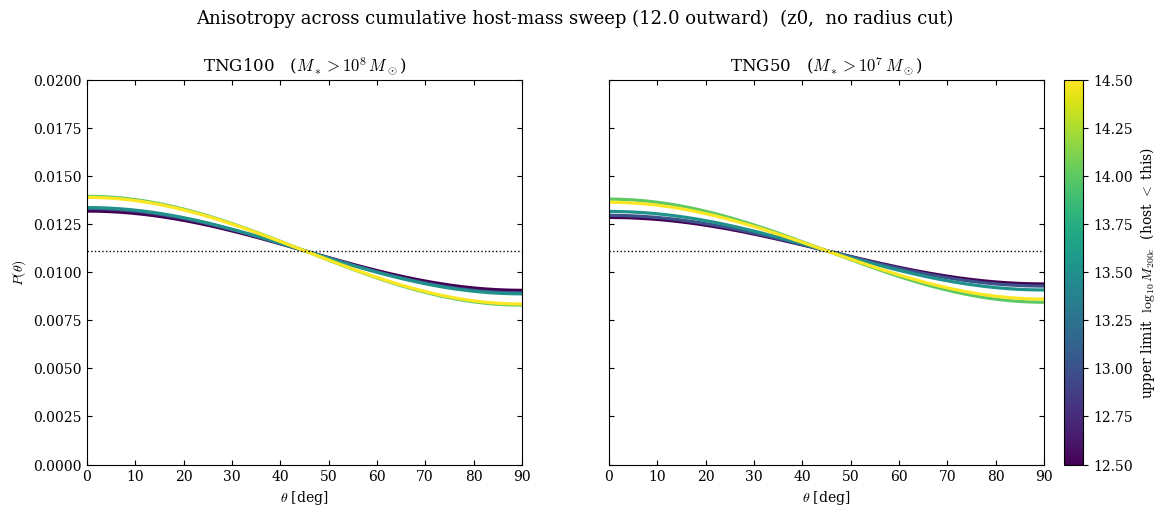

In [4]:
SATLABEL = {8.0: r"$M_* > 10^8\,M_\odot$", 7.0: r"$M_* > 10^7\,M_\odot$"}
_sup = f"{REDZ},  {_rc}"

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (sim, logcut) in zip(axes, PANELS):
    for hlabel, window, hi in CUM_WINDOWS:
        key = (sim, hlabel)
        if key not in fits:
            continue
        f = fits[key]; col = WIN_COLOR[hlabel]
        if np.isfinite(f["A"]):
            x, y = model_curve(f["A"]); ax.plot(x, y, color=col, lw=2.3)
    ax.axhline(1 / 90, color="k", lw=1, ls=":")
    ax.set_xlim(0, 90); ax.set_ylim(0, 0.02)
    ax.set_xlabel(r"$\theta$ [deg]")
    ax.set_title(f"{sim.upper()}   ({SATLABEL.get(logcut, '')})")
    ax.tick_params(which="both", direction="in", top=True, right=True)
axes[0].set_ylabel(r"$P(\theta)$")
cb = fig.colorbar(ScalarMappable(norm=_norm, cmap=_cmap), ax=axes, fraction=0.03, pad=0.02)
cb.set_label(r"upper limit  $\log_{10} M_{200c}$  (host $< $ this)")
fig.suptitle(f"Anisotropy across cumulative host-mass sweep (12.0 outward)  ({_sup})", y=1.02, fontsize=13)
plt.show()

### Figure 2 — quench fraction $f_q(\theta)$ across the cumulative sweep

Same coloring. Bold line + band = MCMC posterior median and 16–84th percentile of
$f_q=a+b\cos2\theta$.

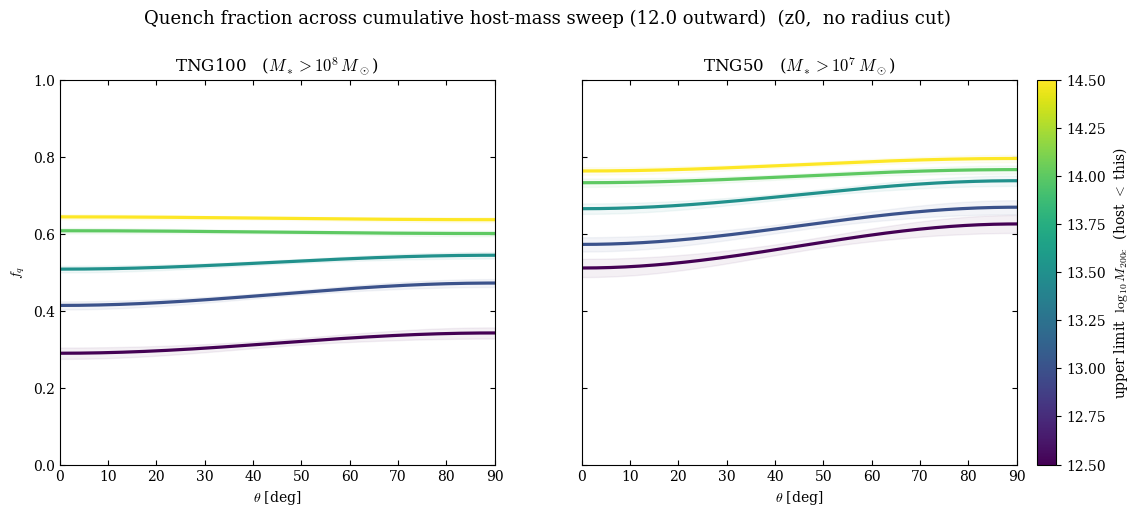

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (sim, logcut) in zip(axes, PANELS):
    for hlabel, window, hi in CUM_WINDOWS:
        key = (sim, hlabel)
        if key not in fq_p:
            continue
        p, e = fq_p[key], fq_e[key]; col = WIN_COLOR[hlabel]
        if np.isfinite(p[1]):
            x, ymed, ylo, yhi = fq_band(p, e)
            ax.plot(x, ymed, color=col, lw=2.3)
            ax.fill_between(x, ylo, yhi, color=col, alpha=0.06)
    ax.set_xlim(0, 90); ax.set_ylim(0, 1)
    ax.set_xlabel(r"$\theta$ [deg]")
    ax.set_title(f"{sim.upper()}   ({SATLABEL.get(logcut, '')})")
    ax.tick_params(which="both", direction="in", top=True, right=True)
axes[0].set_ylabel(r"$f_q$")
cb = fig.colorbar(ScalarMappable(norm=_norm, cmap=_cmap), ax=axes, fraction=0.03, pad=0.02)
cb.set_label(r"upper limit  $\log_{10} M_{200c}$  (host $< $ this)")
fig.suptitle(f"Quench fraction across cumulative host-mass sweep (12.0 outward)  ({_sup})", y=1.02, fontsize=13)
plt.show()

### Figure 3 — $A$, $a$, $b$ vs the host-mass range included

The headline: how the fitted parameters evolve as the cumulative upper limit grows from 12.5 to
$\sim$14.5. $x$-axis = the upper limit ($12.0 < \log M_{200c} < x$). Left: anisotropy amplitude
$A$. Middle: quench baseline $a$ (mean quenched fraction). Right: quench amplitude $b$
($b=0$ = isotropic quenching). Error bars are the MCMC 1$\sigma$.

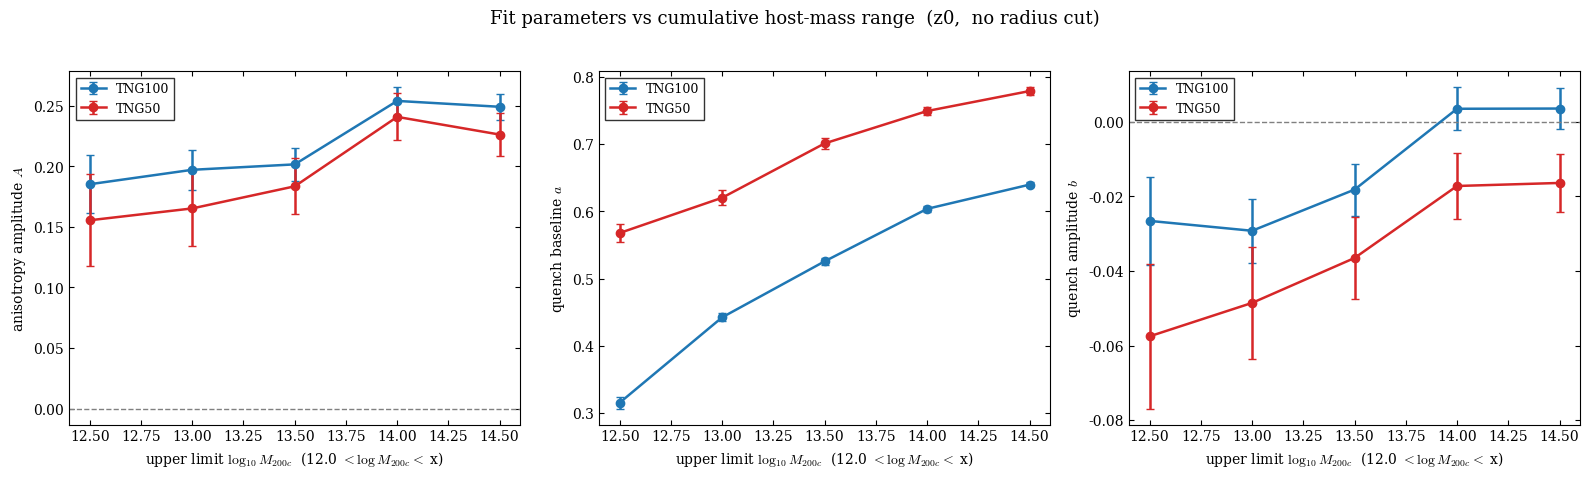

In [6]:
def _series(sim, which):
    xs, ys, es = [], [], []
    for hlabel, window, hi in CUM_WINDOWS:
        key = (sim, hlabel)
        if key not in fits:
            continue
        if which == "A":
            v, err = fits[key]["A"], fits[key]["Aerr"]
        elif which == "a":
            v, err = fq_p[key][0], fq_e[key][0]
        else:  # "b"
            v, err = fq_p[key][1], fq_e[key][1]
        xs.append(hi); ys.append(v); es.append(err)
    return np.array(xs), np.array(ys), np.array(es)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
specs = [("A", r"anisotropy amplitude $A$", True),
         ("a", r"quench baseline $a$",       False),
         ("b", r"quench amplitude $b$",       True)]
for ax, (which, ylab, zeroline) in zip(axes, specs):
    for sim, logcut in PANELS:
        xs, ys, es = _series(sim, which)
        if len(xs) == 0:
            continue
        ax.errorbar(xs, ys, yerr=es, fmt="o-", color=SIMCOL[sim], capsize=3, ms=6, lw=1.8,
                    label=sim.upper())
    if zeroline:
        ax.axhline(0.0, color="grey", ls="--", lw=1)
    ax.set_xlabel(r"upper limit $\log_{10} M_{200c}$  (12.0 $<\log M_{200c}<$ x)")
    ax.set_ylabel(ylab)
    ax.legend(fancybox=False, edgecolor="k", fontsize=9)
    ax.tick_params(which="both", direction="in", top=True, right=True)
fig.suptitle(f"Fit parameters vs cumulative host-mass range  ({_sup})", y=1.03, fontsize=13)
plt.tight_layout(); plt.show()